<a href="https://colab.research.google.com/github/prasadshinde-2005/Discretization/blob/main/Descretization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Discretization


What is Discretization --> It can be conveting Numerical values into categorical variable , by using Binning

Why we use Discretization -
- Reduce the effect of outliers
- Handling Non-linear Relationship
- Reduce Overfitting
- Reduce noise
- Improve interpretability

Binning -> Handel Outlier

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [2]:
# Generaet synthetic data
np.random.seed(0)
x = np.random.normal(0,1,size =(100, 1))
y = 3 * x.squeeze() + np.random.normal(0,1,size =100)

In [25]:
# Indroduce outlier in the data
x[99] = 10
y[99] = 1

In [26]:
# Apply linear regression
lin = LinearRegression().fit(x,y)
y_pred =lin.predict(x)


In [17]:
# Discretize the feature
disc = KBinsDiscretizer(n_bins = 10 , encode ="ordinal" , strategy ="quantile")
x_disc = disc.fit_transform(x)

In [ ]:
# Apply lInear Regression on the discretized feature
lin_disc= LinearRegression()
lin_disc.fit(x_disc , y)
y_pred_disc = lin_disc.predict(x_disc)

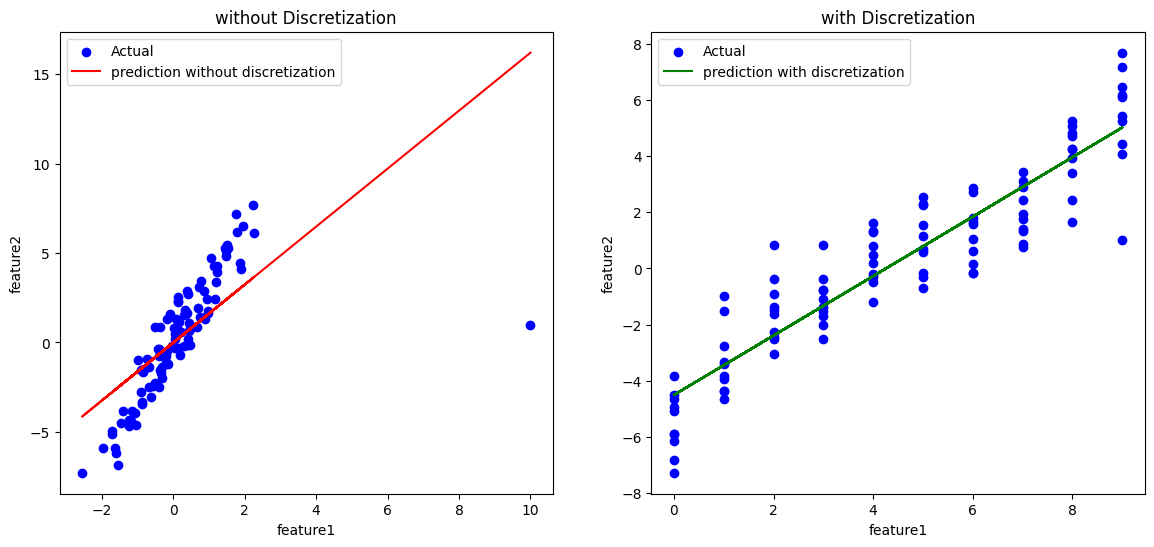

Mse without disc : 5.6283190219885615
Mse with disc : 1.640873628969796


In [30]:
# plotting the result
plt.figure(figsize =(14 , 6))

plt.subplot(1 ,2 ,1)
plt.scatter(x, y, color ="blue",label ="Actual")
plt.plot(x ,y_pred , color ="red" ,label ="prediction without discretization")
plt.title("without Discretization")
plt.xlabel("feature1")
plt.ylabel("feature2")
plt.legend()

plt.subplot(1 ,2 ,2)
plt.scatter(x_disc, y, color ="blue",label ="Actual")
plt.plot(x_disc ,y_pred_disc , color ="green" ,label ="prediction with discretization")
plt.title("with Discretization")
plt.xlabel("feature1")
plt.ylabel("feature2")
plt.legend()
plt.show()

# Calculate and compare MSE
mse_without_disc = mean_squared_error(y , y_pred)
mse_with_disc = mean_squared_error(y , y_pred_disc)
print("Mse without disc :",mse_without_disc)
print("Mse with disc :",mse_with_disc)

Binning for -> Reduce Overfitting

Original Feature - Train MSE: 280.367, Test MSE: 446.553
Discretized Feature - Train MSE: 339.937, Test MSE: 475.515


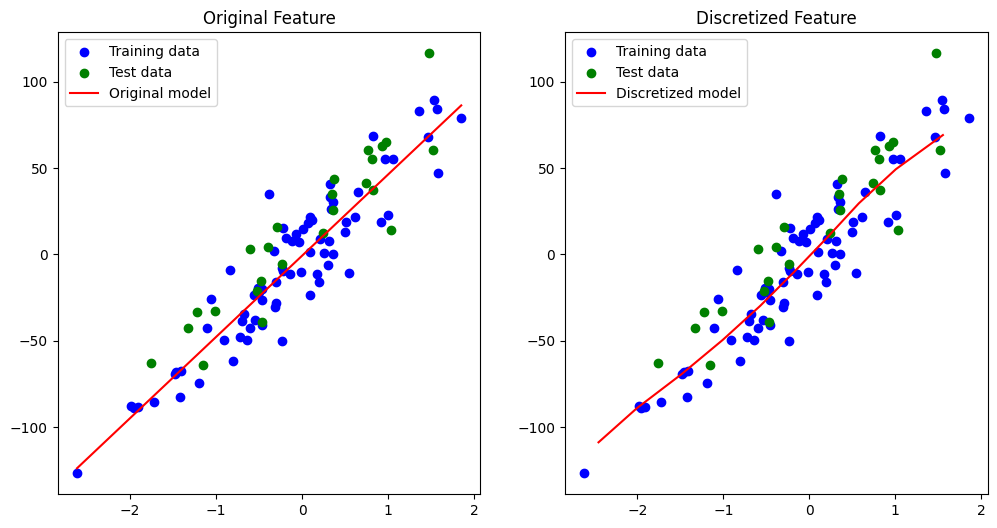

In [179]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import KBinsDiscretizer

# Generate synthetic data
X, y = make_regression(n_samples=100, n_features=1, noise=20, random_state=42)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Linear regression with the original feature
model_original = LinearRegression()
model_original.fit(X_train, y_train)
y_train_pred_orig = model_original.predict(X_train)
y_test_pred_orig = model_original.predict(X_test)

# Discretize the feature
disc = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='kmeans')
X_train_disc = disc.fit_transform(X_train)
X_test_disc = disc.transform(X_test)

# Linear regression with the discretized feature
model_disc = LinearRegression()
model_disc.fit(X_train_disc, y_train)
y_train_pred_disc = model_disc.predict(X_train_disc)
y_test_pred_disc = model_disc.predict(X_test_disc)

# Calculate and print MSE for both models
mse_train_orig = mean_squared_error(y_train, y_train_pred_orig)
mse_test_orig = mean_squared_error(y_test, y_test_pred_orig)
mse_train_disc = mean_squared_error(y_train, y_train_pred_disc)
mse_test_disc = mean_squared_error(y_test, y_test_pred_disc)

print(f'Original Feature - Train MSE: {mse_train_orig:.3f}, Test MSE: {mse_test_orig:.3f}')
print(f'Discretized Feature - Train MSE: {mse_train_disc:.3f}, Test MSE: {mse_test_disc:.3f}')

# Plotting to visualize overfitting
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(X_train, y_train, color='blue', label='Training data')
plt.scatter(X_test, y_test, color='green', label='Test data')
plt.plot(np.sort(X_train, axis=0), model_original.predict(np.sort(X_train, axis=0)), color='red', label='Original model')
plt.title('Original Feature')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(X_train, y_train, color='blue', label='Training data')
plt.scatter(X_test, y_test, color='green', label='Test data')
# For discretized model, predictions are plotted against the mid-point of each bin
bin_edges = disc.bin_edges_[0]
bin_mids = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.plot(bin_mids, model_disc.predict(disc.transform(bin_mids.reshape(-1, 1))), color='red', label='Discretized model')
plt.title('Discretized Feature')
plt.legend()

plt.show()

Binning for - Handling Non linear Realtionship

Shape of X: (100, 1)
Shape of y: (100, 1)


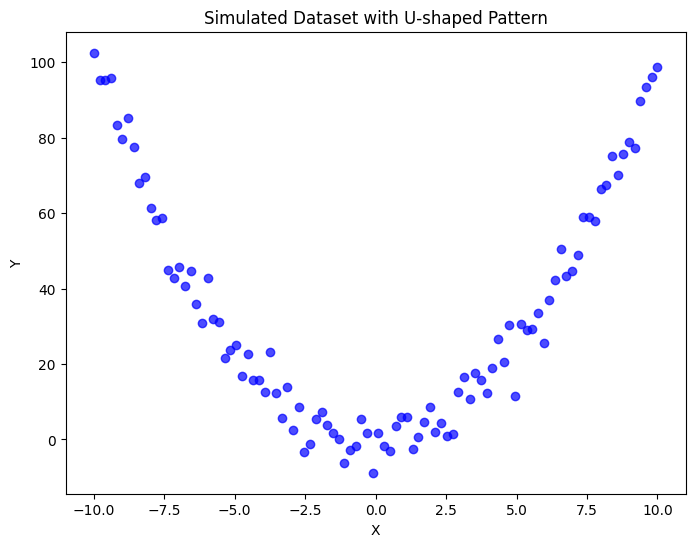

In [180]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import mean_squared_error

# Ensure consistent environment
np.random.seed(42)

# Generate the dataset
X = np.linspace(-10, 10, 100).reshape(-1, 1)  # X is a 100x1 vector
y = X**2 + np.random.normal(0, 5, size=X.shape[0]).reshape(-1,1)  # y is directly based on X, ensuring matching length

# Verify the shapes
print(f"Shape of X: {X.shape}")  # Should print (100, 1)
print(f"Shape of y: {y.shape}")  # Should print (100,)

# Plotting the dataset
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', alpha=0.7)
plt.title('Simulated Dataset with U-shaped Pattern')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()


In [182]:
X_train ,X_test ,Y_train,Y_test = train_test_split(X , y , test_size =0.2 , random_state = 42)

In [183]:
# Fit non-discretized linear regression
model = LinearRegression().fit(X_train ,Y_train)
y_pred = model.predict(X_test)

In [184]:
mse_nd = mean_squared_error(Y_test, y_pred)
mse_nd

848.9193264853433

In [185]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(80, 1)
(20, 1)
(80, 1)
(20, 1)


In [190]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('discretizer', KBinsDiscretizer(encode='onehot', strategy='quantile')),
    ('model', LinearRegression())
])

param_grid = {'discretizer__n_bins': [3, 5, 8, 10, 15, 20]}
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='neg_mean_squared_error')
grid.fit(X_train, Y_train)
print(grid.best_params_)

{'discretizer__n_bins': 20}


In [192]:
X_train_combined = np.hstack([X_train, X_train_discrete.toarray()])

In [193]:
from sklearn.metrics import mean_squared_error

# Pehle predictions banao
y_pred = model_d.predict(x_test_discrete)   # (yaad rahe: variable naming consistent rakho)

# Ab MSE calculate karo
mse = mean_squared_error(Y_test, y_pred)
print("MSE:", mse)

MSE: 432.51357897411253


Types

# 1) Custom bins

Custom Binning is a discretization technique in which the user manually defines the bin ranges based on domain knowledge, business rules, or expert experience.

Unlike Uniform, Quantile, or K-Means Binning, the bin boundaries are not calculated from the data. Instead, they are chosen by the user.

In [3]:

df = pd.read_csv("/content/Titanic_train.csv")


In [4]:
df = df[["Age", "Survived"]].dropna()

In [87]:
df

,Age,Survived
0,22.0,0
1,38.0,1
2,26.0,1
3,35.0,1
4,35.0,0
...,...,...
885,39.0,0
886,27.0,0
887,19.0,1
889,26.0,1


In [69]:
df.shape

(714, 2)

In [88]:
age_bins = [0,18,60,100]
age_labels =["child" ,"Adult" ,"Senior"]

In [89]:
df["Age_group"] = pd.cut(df["Age"] ,bins = age_bins , labels = age_labels , right =False)
df.sample(10)

,Age,Survived,Age_group
721,17.0,0,child
595,36.0,0,Adult
41,27.0,0,Adult
266,16.0,0,child
477,29.0,0,Adult
177,50.0,0,Adult
855,18.0,1,Adult
455,29.0,1,Adult
747,30.0,1,Adult
811,39.0,0,Adult


In [94]:
df[df["Age_group"].isin(["Senior"])].head()

,Age,Survived,Age_group
33,66.0,0,Senior
54,65.0,0,Senior
96,71.0,0,Senior
116,70.5,0,Senior
170,61.0,0,Senior


#  2) Uniform Binning

Uniform Binning is a discretization technique that divides a continuous feature into equal-width intervals (bins). The width of each bin is the same, but the number of observations in each bin may be different.

The bin width is calculated using the formula:

Bin Width = max_value - min_value / no. of bins


In [95]:

age = [18,21,24,27,30,35,40,45,50,55]

df = pd.DataFrame({"Age":age})

df["Range"] = pd.cut(df["Age"], bins = 3)
df["Bin_num"] = pd.cut(df["Age"],bins=3 , labels = False)

print(df)

   Age             Range  Bin_num
0   18  (17.963, 30.333]        0
1   21  (17.963, 30.333]        0
2   24  (17.963, 30.333]        0
3   27  (17.963, 30.333]        0
4   30  (17.963, 30.333]        0
5   35  (30.333, 42.667]        1
6   40  (30.333, 42.667]        1
7   45    (42.667, 55.0]        2
8   50    (42.667, 55.0]        2
9   55    (42.667, 55.0]        2


In [8]:
kbns = KBinsDiscretizer(n_bins = 5 , encode ="ordinal" , strategy="Uniform")

In [25]:
# ex - titanic data
x_train ,x_test ,y_train ,y_test = train_test_split(df[["Age"]],df[["Survived"]] ,test_size = 0.2 , random_state = 42)

In [26]:
x_train.shape

(571, 1)

In [27]:
discretizer = KBinsDiscretizer(n_bins = 5, encode ="ordinal" , strategy ="uniform")
X_train_binned = pd.DataFrame(discretizer.fit_transform(x_train), columns=discretizer.get_feature_names_out())
X_test_binned = pd.DataFrame(discretizer.transform(x_test), columns=discretizer.get_feature_names_out())

X_train_binned.head()

,Age
0,1.0
1,1.0
2,1.0
3,2.0
4,1.0


In [28]:
discretizer.bin_edges_

array([array([ 0.42 , 16.336, 32.252, 48.168, 64.084, 80.   ])],
      dtype=object)

In [29]:
Age_bin_edges = discretizer.bin_edges_[0]

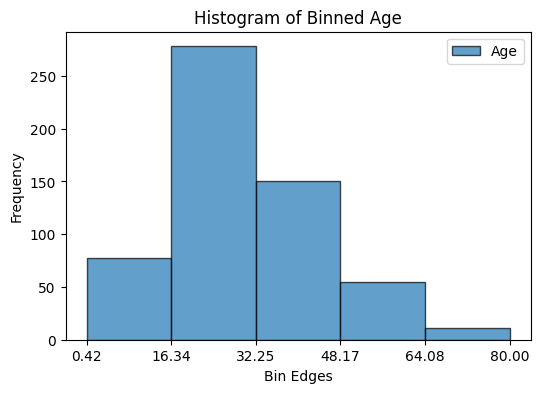

In [31]:
plt.figure(figsize=(6, 4))
# Use the extracted bin edges for plotting
plt.hist(x_train['Age'], bins = Age_bin_edges, alpha=0.7, edgecolor='black', label='Age')
plt.title('Histogram of Binned Age')
plt.xlabel('Bin Edges')
plt.ylabel('Frequency')
plt.xticks(Age_bin_edges)
plt.legend()
plt.show()

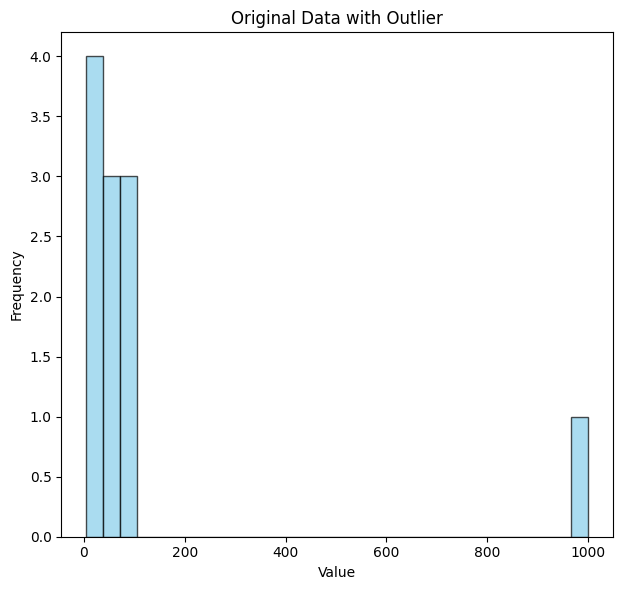

In [32]:
# it can not be handle outlier
# Generating a dataset with values mostly between 0 and 100, with one outlier at 1000
data = np.array([5, 15, 25, 35, 45, 55, 65, 75, 85, 95, 1000])

# Reshape data for KBinsDiscretizer
data_reshaped = data.reshape(-1, 1)  # Convert to 2D array for KBinsDiscretizer

# Define the number of bins
n_bins = 5

# Initialize KBinsDiscretizer
discretizer = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='uniform')

# Fit and transform the data
data_binned = discretizer.fit_transform(data_reshaped).ravel()  # Flatten back to 1D array for plotting

# Plotting the original data and the binned result
plt.figure(figsize=(12, 6))

# Plotting the original data
plt.subplot(1, 2, 1)
plt.hist(data, bins=30, color='skyblue', alpha=0.7, edgecolor='black')
plt.title('Original Data with Outlier')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

#  3) Quantile Binning

Quantile Binning, also known as Equal Frequency Binning, divides a continuous variable into bins so that each bin contains approximately the same number of observations. The widths of the bins can vary depending on the data distribution, making it particularly useful for skewed datasets.

In [35]:
# Example
age = [18,21,24,27,30,35,40,45,50,55]

df = pd.DataFrame({"Age":age})


df["Range"] = pd.qcut(df["Age"], q=4)
df["Bin_number"] = pd.qcut(df["Age"], q=4 , labels =False)

print(df)

   Age            Range  Bin_number
0   18  (17.999, 24.75]           0
1   21  (17.999, 24.75]           0
2   24  (17.999, 24.75]           0
3   27    (24.75, 32.5]           1
4   30    (24.75, 32.5]           1
5   35    (32.5, 43.75]           2
6   40    (32.5, 43.75]           2
7   45    (43.75, 55.0]           3
8   50    (43.75, 55.0]           3
9   55    (43.75, 55.0]           3


In [37]:
# Quantile binning ON titanic data
disc = KBinsDiscretizer(n_bins = 5 ,encode ="ordinal", strategy = "quantile")

x_train_binned = pd.DataFrame(disc.fit_transform(x_train), columns=discretizer.get_feature_names_out())
x_test_binned = pd.DataFrame(disc.transform(x_test), columns=discretizer.get_feature_names_out())

x_train_binned.head()

,Age
0,2.0
1,2.0
2,2.0
3,3.0
4,2.0


In [38]:
disc.bin_edges_

array([array([ 0.42, 19.  , 25.  , 32.  , 42.  , 80.  ])], dtype=object)

In [39]:
Age_bins = disc.bin_edges_[0]

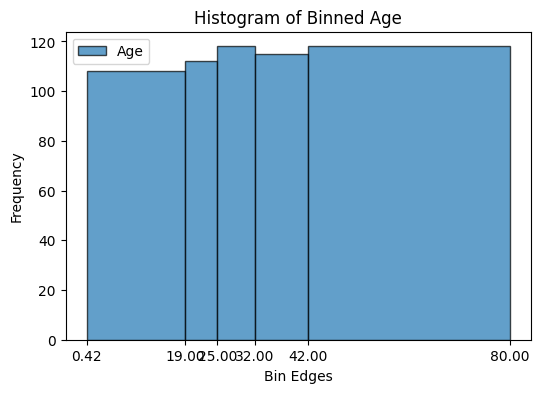

In [50]:
plt.figure(figsize=(6, 4))
# Use the extracted bin edges for plotting
plt.hist(x_train['Age'], bins = Age_bins, alpha=0.7, edgecolor='black', label='Age')
plt.title('Histogram of Binned Age')
plt.xlabel('Bin Edges')
plt.ylabel('Frequency')
plt.xticks(Age_bins)
plt.legend()
plt.show()

# 4) K-means Binning

K-Means Binning is a discretization technique that uses the K-Means clustering algorithm to divide a continuous feature into K bins based on the natural grouping of the data. Unlike Uniform Binning and Quantile Binning, how much bins are required , we can find by using elbo methos and silhouate score

In [5]:
df.head()

,Age,Survived
0,22.0,0
1,38.0,1
2,26.0,1
3,35.0,1
4,35.0,0


In [45]:
kmeans = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='kmeans')

X_train_binned = pd.DataFrame(kmeans.fit_transform(x_train), columns=discretizer.get_feature_names_out())
X_test_binned = pd.DataFrame(kmeans.transform(x_test), columns=discretizer.get_feature_names_out())

X_train_binned.head()

,Age
0,2.0
1,1.0
2,2.0
3,2.0
4,1.0


In [47]:
bin_range = kmeans.bin_edges_[0]

In [48]:
print(bin_range)

[ 0.42       12.69636862 27.02765256 39.35418895 54.21464646 80.        ]


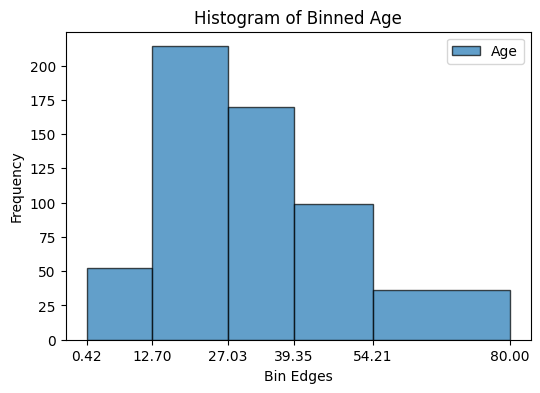

In [51]:
plt.figure(figsize=(6, 4))
# Use the extracted bin edges for plotting
plt.hist(x_train['Age'], bins= bin_range , alpha=0.7, edgecolor='black', label='Age')
plt.title('Histogram of Binned Age')
plt.xlabel('Bin Edges')
plt.ylabel('Frequency')
plt.xticks(bin_range)
plt.legend()
plt.show()

# 5) Binarization

Threshold Binning is a discretization technique where continuous values are divided into bins using predefined threshold values instead of calculating them from the data.

In [52]:
from sklearn.preprocessing import Binarizer

# Sample data
data = [[-1, 2, -3], [5, -6, 7] ,[-22 ,19, 76]]

# Initialize the Binarizer with a threshold of 0
binarizer = Binarizer(threshold=0)

# Transform the data
binary_data = binarizer.fit_transform(data)

print(binary_data)

[[0 1 0]
 [1 0 1]
 [0 1 1]]


# 6) Decision_tree based Binning

Decision Tree Binning is a discretization technique that uses a Decision Tree algorithm to find the optimal split points (bins) in a continuous feature based on the target variable.

Unlike Uniform, Quantile, or K-Means Binning, it is a supervised method because it considers both the feature (X) and the target (y).

In [122]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np

# Sample data (feature and target)
X = np.array([[6], [12], [14], [18], [22], [24], [29], [33], [37], [40]])
y = np.array([0, 0, 0, 1, 1, 0, 1, 1, 1, 1])  # Binary target for simplicity

# Train a decision tree on the data
tree = DecisionTreeClassifier(max_leaf_nodes=4)  # Restricting tree size for simple binning
tree.fit(X, y)

DecisionTreeClassifier(max_leaf_nodes=4)

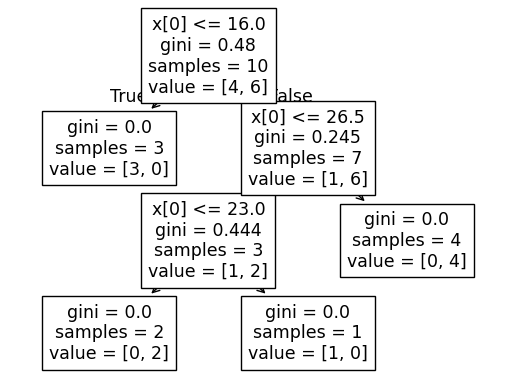

In [123]:
from sklearn.tree import plot_tree
plot_tree(tree)
plt.show()

In [124]:
tree.tree_.threshold

array([16. , -2. , 26.5, 23. , -2. , -2. , -2. ])

In [125]:
# Extract split points (thresholds) from the tree to define bin edges
split_points = tree.tree_.threshold[tree.tree_.threshold != -2]
split_points

array([16. , 26.5, 23. ])

In [126]:
# Add the minimum and maximum values to cover the full range of X
bin_edges = np.sort(np.concatenate(([X.min()], split_points, [X.max()])))

print("Bin edges:", bin_edges)

Bin edges: [ 6.  16.  23.  26.5 40. ]


In [127]:
# Function to assign bins
def assign_bins(data, edges):
    bins = np.digitize(data, edges, right=False)  # Assign bins based on edges
    # Adjusting bins to be 1-indexed instead of 0-indexed
    # and ensuring values fall into n_bins categories
    bins = np.clip(bins, 1, len(edges)-1)
    return bins

In [128]:
# Assign each data point to a bin
bins_assigned = assign_bins(X, bin_edges)

# Print the assigned bins for each data point
for value, bin_num in zip(X.flatten(), bins_assigned):
    print(f"Value: {value} assigned to Bin: {bin_num}")

Value: 6 assigned to Bin: [1]
Value: 12 assigned to Bin: [1]
Value: 14 assigned to Bin: [1]
Value: 18 assigned to Bin: [2]
Value: 22 assigned to Bin: [2]
Value: 24 assigned to Bin: [3]
Value: 29 assigned to Bin: [4]
Value: 33 assigned to Bin: [4]
Value: 37 assigned to Bin: [4]
Value: 40 assigned to Bin: [4]


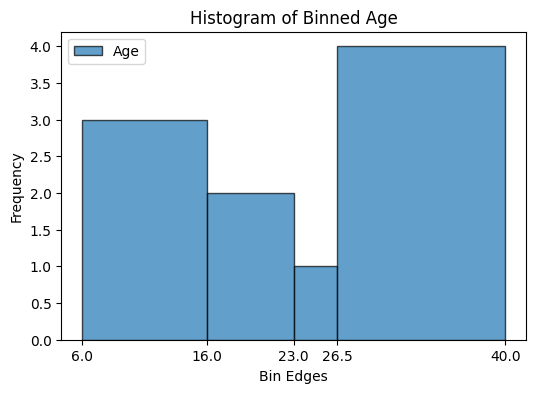

In [130]:
plt.figure(figsize=(6, 4))
# Use the extracted bin edges for plotting
plt.hist(X ,bins = bin_edges , alpha=0.7, edgecolor='black', label='Age')
plt.title('Histogram of Binned Age')
plt.xlabel('Bin Edges')
plt.ylabel('Frequency')
plt.xticks(bin_edges)
plt.legend()
plt.show()

In [103]:
# Decision tree binning
Tree = DecisionTreeClassifier(max_leaf_nodes = 12)
Tree.fit(x_train , y_train)

DecisionTreeClassifier(max_leaf_nodes=12)

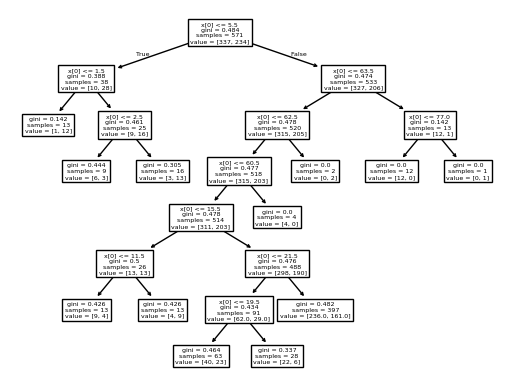

In [104]:
plot_tree(Tree)
plt.show()

In [105]:
Tree.tree_.threshold

array([ 5.5,  1.5, 63.5, 62.5, 77. , -2. , -2. , 60.5, -2. , -2. ,  2.5,
       -2. , -2. , 15.5, -2. , 11.5, 21.5, -2. , -2. , 19.5, -2. , -2. ,
       -2. ])

In [106]:
split_points_= Tree.tree_.threshold[Tree.tree_.threshold != -2]
split_points_

array([ 5.5,  1.5, 63.5, 62.5, 77. , 60.5,  2.5, 15.5, 11.5, 21.5, 19.5])

In [107]:
print(x_train.min())
print(x_train.max())

Age    0.42
dtype: float64
Age    80.0
dtype: float64


In [108]:
min_value = x_train.iloc[:, 0].min()
max_value = x_train.iloc[:, 0].max()

In [109]:
# Add the minimum and maximum values to cover the full range of
bins_ranges = np.sort(np.concatenate(([min_value], split_points_, [max_value])))

print("Bin edges:", bins_ranges)

Bin edges: [ 0.42  1.5   2.5   5.5  11.5  15.5  19.5  21.5  60.5  62.5  63.5  77.
 80.  ]


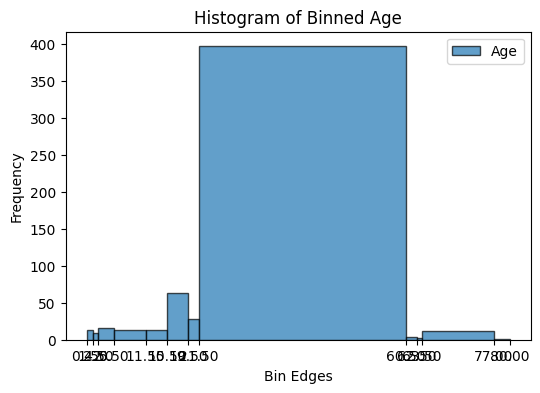

In [111]:
plt.figure(figsize=(6, 4))
# Use the extracted bin edges for plotting
plt.hist(x_train ,bins = bins_ranges , alpha=0.7, edgecolor='black', label='Age')
plt.title('Histogram of Binned Age')
plt.xlabel('Bin Edges')
plt.ylabel('Frequency')
plt.xticks(bins_ranges)
plt.legend()
plt.show()

In [112]:
print(split_points_)
print(bins_ranges)
print(pd.cut(x_train.squeeze(), bins=bins_ranges).value_counts().sort_index())

[ 5.5  1.5 63.5 62.5 77.  60.5  2.5 15.5 11.5 21.5 19.5]
[ 0.42  1.5   2.5   5.5  11.5  15.5  19.5  21.5  60.5  62.5  63.5  77.
 80.  ]
Age
(0.42, 1.5]      12
(1.5, 2.5]        9
(2.5, 5.5]       16
(5.5, 11.5]      13
(11.5, 15.5]     13
(15.5, 19.5]     63
(19.5, 21.5]     28
(21.5, 60.5]    397
(60.5, 62.5]      4
(62.5, 63.5]      2
(63.5, 77.0]     12
(77.0, 80.0]      1
Name: count, dtype: int64
